In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_parquet(
    "hf://datasets/AlekseyKorshuk/quora-question-pairs/data/train-00000-of-00001.parquet"
)
df.shape

(404290, 6)

In [ ]:
df.to_csv("quora_train.csv", index=False)

In [4]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
46547,46547,83244,83245,Is it impossible to reduce gun violence and gu...,What is the root cause of mass gun violence in...,0
14909,14909,5567,28521,What is the first law of thermodynamics and wh...,What is the first law of thermodynamics? What ...,1
155508,155508,243610,177446,What are the best design schools?,What's the best graphic design school?,0
178820,178820,140185,114105,What is the best laptop under 60000 Indian Rup...,Which is the best laptop available in India in...,1
31421,31421,57931,57932,What is the depth of Grand Canyon?,I Got offer from infosys and total gross salar...,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [6]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

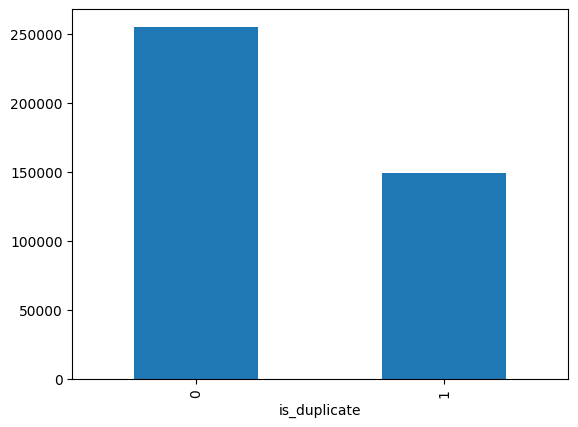

In [9]:
# DIstribution of duplicate & non-duplicate rows

print(df["is_duplicate"].value_counts())
print()
print((df["is_duplicate"].value_counts() / df["is_duplicate"].count()) * 100)
df["is_duplicate"].value_counts().plot(kind="bar")

---
## Running `RandomForest` without any optimizations

In [4]:
new_df = df.sample(60000)
new_df.dropna()
new_df.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [5]:
ques_df = new_df[["question1", "question2"]]
ques_df.head(2)

,question1,question2
202615,What are the major differences between Chinese...,What is the difference between Chinese and wes...
210295,What's up with 4chan?,Why are people on 4chan so mean?


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

questions = list(ques_df["question1"]) + list(ques_df["question2"])

cv = CountVectorizer(max_features=3000)
q1_arr, q2_arr = np.vsplit(cv.fit_transform(questions).toarray(), 2)

In [7]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print(temp_df.shape)

(60000, 6000)


In [ ]:
temp_df["is_duplicate"] = new_df["is_duplicate"]

In [9]:
temp_df.head(2)

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,is_duplicate
202615,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
210295,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    temp_df.iloc[:, 0:-1].values, temp_df.iloc[:, -1].values, test_size=0.2
)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
accuracy_score(y_test, y_pred)

0.7681666666666667